In [27]:
import mysql.connector
from mysql.connector import Error

import pandas as pd

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [28]:

user_db = 'Equipo23'
password_db = 'E1q2u3i4p5o23'
host_db = '212.227.90.6'
database_name = 'Equip_23'


try:
    conexion = mysql.connector.connect(
        user=user_db,
        password=password_db,
        host=host_db,
        database=database_name,
        
    )
    print("¡Conexión a MySQL establecida con éxito!")

except Exception as e:
    print(f"Error al conectar a MySQL: {e}")



¡Conexión a MySQL establecida con éxito!


In [29]:

query = "SELECT * FROM BANK_marketing;"              
df_bank = pd.read_sql(query, conexion)

df_bank

C:\Users\usuario\AppData\Local\Temp\ipykernel_19396\3700078070.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_bank = pd.read_sql(query, conexion)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10637,10638,33.0,technician,married,secondary,no,218,yes,yes,telephone,2,mar,169,4,-1,0,unknown,no
10638,10639,42.0,management,single,tertiary,no,1146,yes,no,unknown,15,may,98,2,-1,0,unknown,no
10639,10640,31.0,unemployed,single,unknown,no,167,no,no,cellular,20,nov,316,1,-1,0,unknown,no
10640,10641,30.0,blue-collar,single,secondary,yes,447,no,no,cellular,19,nov,426,2,189,6,failure,no


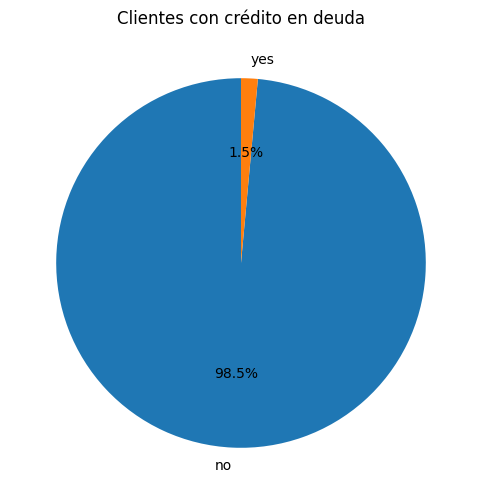

In [34]:
# preparamos los datos
grafico = df_bank['default'].value_counts()

# dibujamos el gráfico
grafico.plot.pie(autopct='%1.1f%%', figsize=(6,6), startangle=90)

plt.title('Clientes con crédito en deuda')
plt.ylabel('')
plt.show()

Solo un 1,5 % de los clientes tienen credito en déuda

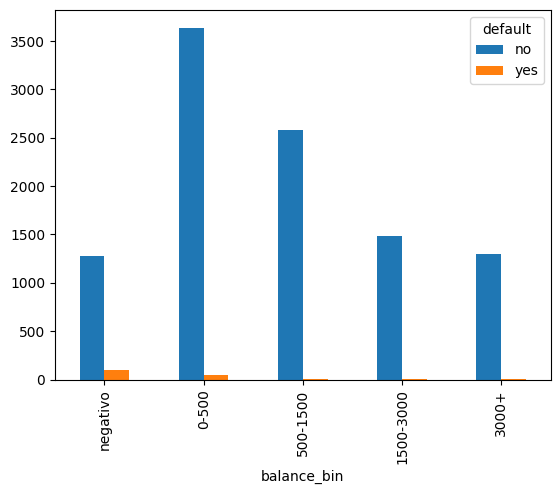

In [30]:


df_bank['balance_bin'] = pd.cut(df_bank['balance'],
                                bins=[-2000, 0, 500, 1500, 3000, 10000],
                                labels=['negativo', '0-500', '500-1500', '1500-3000', '3000+'])

pd.crosstab(df_bank['balance_bin'], df_bank['default']).plot.bar()
plt.show()


Hay más clientes con crédito en deuda en los saldos más bajos y especialmente en los negativos

<Axes: xlabel='default', ylabel='balance'>

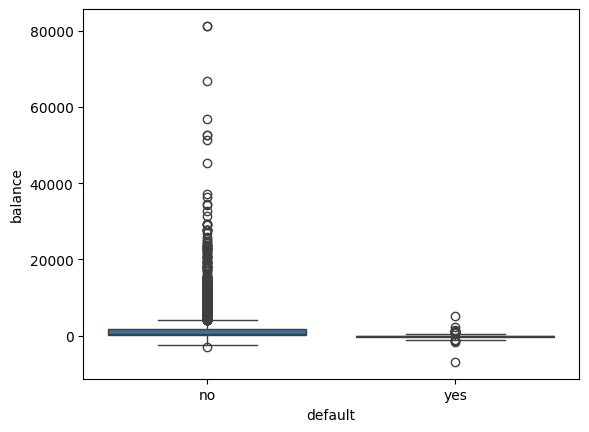

In [31]:
sns.boxplot(x='default', y='balance', data=df_bank)


Los clientes con crédito en deuda tienen saldos más bajos y la mediana es inferior, tienen menos variabilidad.

Esto indica que los clientes con saldos más bajos presentan mayor riesgo de impago de su crédito ya que no tienen dinero para pagarlo *(obvio)*.

## Resultados del análisis

Los resultados muestran que los clientes con saldos más bajos presentan un mayor riesgo de impago. 
Para reducir este riesgo sin excluir a ningun cliente, la entidad puede aplicar medidas como:

**1. Análisis del tipo de riesgo** Se realiza un análisis más exaustivo del historial de pagos y el tipo de cliente que es para adaptar las condiciones del crédito a su perfil financiero

**2. Programas de educación financiera** Ofrecer asesoramiento o formación a clientes con saldos bajos para ayudarles a mejorar su gestión económica y reducir el riesgo de impago

**3. Ajustar la cantidad de crédito inicial** Se ofrecen créditos iniciales más bajos y se puede aumentar esta cantidad en función del comportamiento de pagos. Esto ayudará a controlar el riesgo sin excluir a nadie.

**3. Acompañamiento** Los clientes con saldos bajos recibirán más atencion para ajustar las condiciones en tiempo real. 

# Anotaciones

*He intentado hacer unas políticas muy inclusivas y suaves para no marginar a ningun tipo de cliente xD*

Estaba pensando en analizar que tipo de cliente es el que tiene las deudas pero creo que no lo piden. 